In [111]:
import os
import numpy as np
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.time import Time
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import matplotlib.pyplot as plt

In [112]:
# file directory
object_dir = r"E:\WORKS\Master_works\GW2025\homework\hw7\GTCMULTIPLE7A-23B\OB0033\object"
flat_dir = r"E:\WORKS\Master_works\GW2025\homework\hw7\GTCMULTIPLE7A-23B\OB0033\flat"
flat_files = [f for f in os.listdir(flat_dir) if "FLAT.fits" in f and f.endswith(".fits")]
flat_paths = [os.path.join(flat_dir, f) for f in flat_files]
flat_data_list = []
for path in flat_paths:
    with fits.open(path) as hdu:
        flat_data = hdu[0].data.astype(np.float32)
        flat_data_list.append(flat_data)
mean_flat = np.mean(flat_data_list, axis=0)

# normalization
mean, median, std = sigma_clipped_stats(mean_flat, sigma=3)
normalized_flat = mean_flat / mean
print("Flat finished (normalized)")

Flat finished (normalized)


In [113]:
object_files = [f for f in os.listdir(object_dir) if "STARE_IMAGE.fits" in f and f.endswith(".fits")]
object_paths = [os.path.join(object_dir, f) for f in object_files]
obs_info = []
for path in object_paths:
    with fits.open(path) as hdu:
        header = hdu[0].header
        if "MJD-OBS" in header:
            mjd = float(header["MJD-OBS"])
        elif "DATE-OBS" in header:
            utc_str = header["DATE-OBS"]
            mjd = Time(utc_str, format="isot").mjd  # convert to mjd
        obs_info.append((path, mjd))
obs_info.sort(key=lambda x: x[1])
sorted_paths = [x[0] for x in obs_info]
sorted_mjds = [x[1] for x in obs_info]
# print(sorted_paths)
# print(sorted_mjds)
print("Time sorted")

Time sorted


In [105]:
calibrated_images = []
valid_flat_pixels = normalized_flat[normalized_flat > 0]
flat_min_threshold = np.percentile(valid_flat_pixels, 1) # %1分位点作为最小平场值
processed_flat = np.where(normalized_flat >= flat_min_threshold, normalized_flat, flat_min_threshold)
for path in sorted_paths:
    with fits.open(path) as hdu:
        sci_data = hdu[0].data.astype(np.float32) 
        calibrated = sci_data / processed_flat  # flat
        calibrated_images.append(calibrated)
print("Calibration finished")

Calibration finished


Target location：x=1066, y=1028


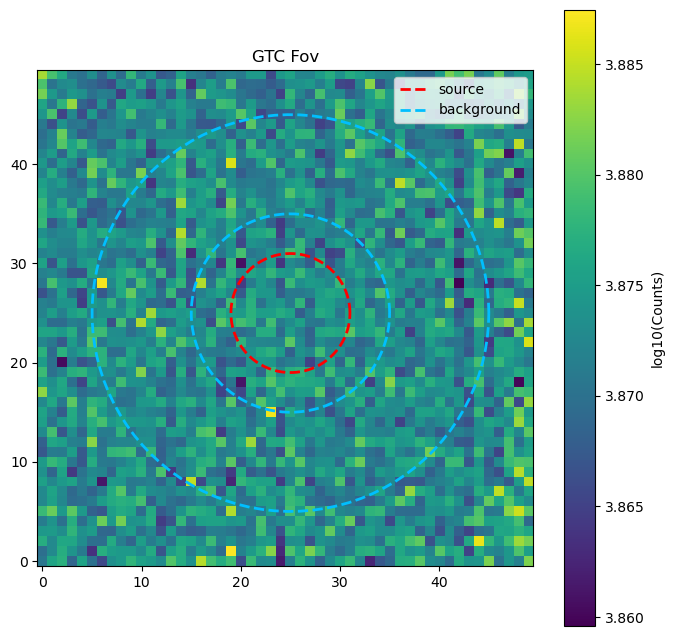

In [163]:
# coordinate
grb_ra = "05h20m07.37s"  
grb_dec = "+25d31m58s" 
grb_coord = SkyCoord(grb_ra, grb_dec, frame="icrs", unit=(u.hourangle, u.deg))

with fits.open(sorted_paths[0]) as hdu:
    wcs = WCS(hdu[0].header) 

grb_x, grb_y = wcs.world_to_pixel(grb_coord)
grb_x, grb_y = int(round(grb_x.item())), int(round(grb_y.item()))
print(f"Target location：x={grb_x}, y={grb_y}")

plt.figure(figsize=(8, 8))
cutout = calibrated_images[0][grb_y-25:grb_y+25, grb_x-25:grb_x+25]
plt.imshow(np.log10(cutout), cmap="viridis", origin="lower")
circle_radius = 6 
center_x, center_y = 25, 25 

theta = np.linspace(0, 2*np.pi, 100)
circle_x = center_x + circle_radius * np.cos(theta)  
circle_y = center_y + circle_radius * np.sin(theta)
circle_x1 = center_x + 10 * np.cos(theta)  
circle_y1 = center_y + 10 * np.sin(theta)
circle_x2 = center_x + 20 * np.cos(theta)  
circle_y2 = center_y + 20 * np.sin(theta)
plt.plot(
    circle_x, circle_y,
    color='red',
    linewidth=2,
    linestyle='--',
    label = 'source'
)
plt.plot(
    circle_x1, circle_y1,
    color='deepskyblue',
    linewidth=2,
    linestyle='--',
)
plt.plot(
    circle_x2, circle_y2,
    color='deepskyblue',
    linewidth=2,
    linestyle='--',
    label = 'background'
)
'''
plt.plot(
    25, 25, 
    marker='o',          
    linestyle='--',        
    markeredgecolor='blue', 
    markerfacecolor='none', 
    markeredgewidth=2,   
    markersize=5,
    dashes=[5, 3]
)
'''
plt.title("GTC Fov")
plt.colorbar(label="log10(Counts)")
plt.legend()
plt.savefig('reg.png')
plt.show()

In [169]:
r_pix = 6  # radius(孔径参数)
target_aperture = CircularAperture((grb_x, grb_y), r=r_pix)

r_in = 10  
r_out = 20 
bg_annulus = CircularAnnulus((grb_x, grb_y), r_in=r_in, r_out=r_out) # background range

fluxes = []  
flux_errors = [] 
exptimes = []

# exposure time
for idx, img in enumerate(calibrated_images):
    with fits.open(sorted_paths[idx]) as hdu:
        exptime = float(hdu[0].header["EXPTIME"])
        exptimes.append(exptime)
    
    phot_table = aperture_photometry(img, [target_aperture, bg_annulus])
    
    # background counts
    bg_sum = phot_table["aperture_sum_1"][0]
    bg_area = bg_annulus.area
    bg_mean = bg_sum / bg_area  #
    
    # net flux（总计数，counts）
    target_sum = phot_table["aperture_sum_0"][0]
    target_area = target_aperture.area
    net_flux_total = target_sum - (bg_mean * target_area)  # scaling
    
    net_flux_rate = net_flux_total / exptime
    
    target_noise = np.sqrt(target_sum)
    bg_noise = bg_mean * np.sqrt(target_area**2 / bg_area)  
    net_flux_err_total = np.sqrt(target_noise**2 + bg_noise**2)  
    net_flux_err_rate = net_flux_err_total / exptime  
    
    fluxes.append(net_flux_rate) 
    flux_errors.append(net_flux_err_rate) 

fluxes = np.array(fluxes)
flux_errors = np.array(flux_errors)
exptimes = np.array(exptimes)

'''
for img in calibrated_images:
    # Total counts
    phot_table = aperture_photometry(img, [target_aperture, bg_annulus])
    
    # background counts
    bg_sum = phot_table["aperture_sum_1"][0]
    bg_area = bg_annulus.area
    bg_mean = bg_sum / bg_area
    
    # net flux in the target area
    target_sum = phot_table["aperture_sum_0"][0]
    target_area = target_aperture.area
    net_flux = target_sum - (bg_mean * target_area) # scaling
    
    # error estimation
    target_noise = np.sqrt(target_sum)
    bg_noise = bg_mean * np.sqrt(target_area**2 / bg_area) # poisson noise
    net_flux_err = np.sqrt(target_noise**2 + bg_noise**2)
    
    fluxes.append(net_flux)
    flux_errors.append(net_flux_err)'''

fluxes = np.array(fluxes)
flux_errors = np.array(flux_errors)
print("Aperture finished")

Aperture finished


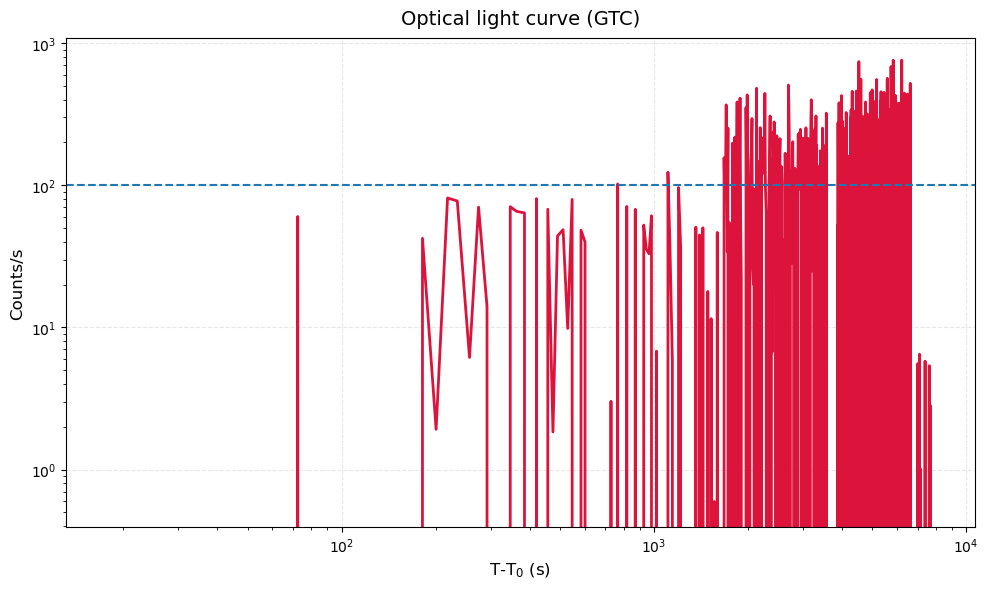

In [171]:
grb_burst_mjd = np.min(sorted_mjds)

delta_t = (np.array(sorted_mjds) - grb_burst_mjd) * 86400 # seconds
plt.rcParams['font.family'] = 'DejaVu Sans' 
plt.figure(figsize=(10, 6))


plt.plot(
    delta_t, fluxes,
    color="crimson", markersize=6, linewidth=2
)

plt.axhline(1e2, 0,1, linestyle = '--')
plt.xlabel(r"T-$\rm T_{0}$ (s)", fontsize=12)
plt.ylabel("Counts/s", fontsize=12)
plt.xscale("log") 
plt.yscale("log")
# plt.xlim(6*10**(3), 8*10**3)

plt.title("Optical light curve (GTC)", fontsize=14, pad=10)
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig('LC.png')
plt.show()